## Importando as Bibliotecas

In [4]:
# Manipulação de dados
import re
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# LDA
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF


nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

print("Bibliotecas Importadas com Sucesso!!")

Bibliotecas Importadas com Sucesso!!


## Leitura da Base de Dados

In [5]:
dados = pd.read_csv("../data/dataset_tratado.csv", index_col=0)
dados.head()

,review_comment_message,review_score,sentimento
3,Recebi bem antes do prazo estipulado.,5,positivo
4,Parabéns lojas lannister adorei comprar pela I...,5,positivo
9,aparelho eficiente. no site a marca do aparelh...,4,positivo
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,positivo
15,"Vendedor confiável, produto ok e entrega antes...",5,positivo


# 1. Limpeza e Preparação dos Dados

In [6]:
CONTRACTIONS = {
    'vc': 'você', 'tb': 'também', 'tbm': 'também', 'pq': 'por que', 'obg': 'obrigado', 'blz': 'beleza',
    'td': 'tudo', 'msm': 'mesmo', 'vlw': 'valeu', 'n': 'não', 'naum': 'não', 'cmprar': 'comprar',
    'mt': 'muito', 'pra': 'para'
}

In [7]:
STOP_WORDS = set(stopwords.words("portuguese"))

NEGACAO = {"não", "nao", "nunca", "nem", "sem"}

STOP_WORDS_PT = STOP_WORDS - NEGACAO

In [8]:
def pipeline_texto(texto):

    # 1. Lowercase
    texto = texto.lower()
    # 2. Remove HTML
    texto = re.sub(r'<[^>]+>', ' ', texto)
    # 3. Remove URLs
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)
    # 4. Remove e-mails
    texto = re.sub(r'\S+@\S+', ' ', texto)
    # 5. Expande contrações
    # Primeiro quebra o texto em palavras (texto.split())
    # Depois troca as contrações no dicionário (CONTRACTIONS)
    # Por fim junta tudo
    palavras = [CONTRACTIONS.get(p,p) for p in texto.split()]
    texto = " ".join(palavras)

    # 6. Remove caracteres indesejados
    texto = re.sub(r'[^a-záàâãéêèíìîóôõöúùûüç\s.,!?]', ' ', texto)

    # 7. Normaliza espaços
    texto = re.sub(r'\s+', ' ', texto).strip()

    # Tokenizando os textos
    tokens = word_tokenize(texto, language="portuguese")

    # Remover as stop words
    texto_limpo = []
    for token in tokens:
        if (token.isalpha() and token not in STOP_WORDS_PT):
            texto_limpo.append(token)
    
    return texto_limpo

In [9]:
dados["review"] = dados["review_comment_message"].apply(pipeline_texto)

dados[["review_comment_message", "review"]].head()

,review_comment_message,review
3,Recebi bem antes do prazo estipulado.,"[recebi, bem, antes, prazo, estipulado]"
4,Parabéns lojas lannister adorei comprar pela I...,"[parabéns, lojas, lannister, adorei, comprar, ..."
9,aparelho eficiente. no site a marca do aparelh...,"[aparelho, eficiente, site, marca, aparelho, i..."
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n","[pouco, travando, valor, ta, boa]"
15,"Vendedor confiável, produto ok e entrega antes...","[vendedor, confiável, produto, ok, entrega, an..."


# 2. LDA - Latent Dirichletr Allocation

In [10]:
tokens = dados["review"].tolist()

dicionario = corpora.Dictionary(tokens)

In [11]:
corpus = [dicionario.doc2bow(doc) for doc in tokens]

In [12]:
lda = LdaModel(
    corpus=corpus,
    id2word=dicionario,
    num_topics=5,
    passes=20,
    random_state=42
)

In [13]:
for numero, topico in lda.print_topics(
    num_topics=5,
    num_words=10
):
    print(f"Tópico {numero}:")
    print(topico)
    print()

Tópico 0:
0.065*"produto" + 0.064*"entrega" + 0.057*"qualidade" + 0.054*"recomendo" + 0.032*"gostei" + 0.030*"rápida" + 0.030*"excelente" + 0.029*"loja" + 0.027*"super" + 0.026*"boa"

Tópico 1:
0.089*"não" + 0.065*"recebi" + 0.062*"produto" + 0.027*"ainda" + 0.021*"comprei" + 0.019*"entregue" + 0.016*"dia" + 0.015*"entrega" + 0.014*"chegou" + 0.013*"compra"

Tópico 2:
0.024*"sempre" + 0.023*"lannister" + 0.017*"ok" + 0.015*"comprar" + 0.012*"tudo" + 0.012*"produtos" + 0.011*"loja" + 0.010*"site" + 0.010*"lojas" + 0.010*"ter"

Tópico 3:
0.057*"não" + 0.046*"produto" + 0.044*"veio" + 0.016*"comprei" + 0.011*"contato" + 0.009*"diferente" + 0.009*"cor" + 0.008*"caixa" + 0.008*"porém" + 0.008*"pedi"

Tópico 4:
0.116*"prazo" + 0.102*"produto" + 0.079*"antes" + 0.061*"chegou" + 0.061*"bom" + 0.042*"bem" + 0.030*"entrega" + 0.030*"entregue" + 0.026*"tudo" + 0.026*"ótimo"



## Calculando a Coherence Score

In [14]:
coherence = CoherenceModel(
    model=lda,
    texts=tokens,
    dictionary=dicionario,
    coherence="c_v"
)

print(f"Coherence: {coherence.get_coherence()}")

Coherence: 0.47010755771225277


## Testando Números de Tópicos

In [15]:
quantidades_topicos = [3, 5, 7]

resultados_coerencia = []

for n_topicos in quantidades_topicos:

    modelo_lda = LdaModel(
        corpus=corpus,
        id2word=dicionario,
        num_topics=n_topicos,
        passes=20,
        random_state=42
    )

    coherence_modelo = CoherenceModel(
        model=modelo_lda,
        texts=tokens,
        dictionary=dicionario,
        coherence="c_v"
    )

    coherence_score = coherence_modelo.get_coherence()

    resultados_coerencia.append({
        "num_topics": n_topicos,
        "coherence": coherence_score
    })

    print(f"Tópico -> {n_topicos} | Coherence -> {coherence_score}")

Tópico -> 3 | Coherence -> 0.43226625554951664
Tópico -> 5 | Coherence -> 0.47010755771225277
Tópico -> 7 | Coherence -> 0.45128904979406653


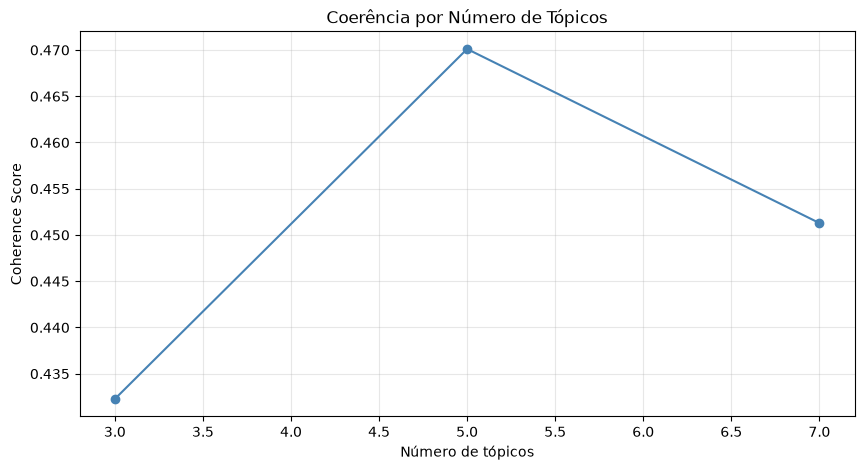

In [16]:
df_resultado = pd.DataFrame(resultados_coerencia)

plt.figure(figsize=(10,5))

plt.plot(df_resultado["num_topics"], df_resultado["coherence"], marker="o", color="steelblue")

plt.title("Coerência por Número de Tópicos")
plt.xlabel("Número de tópicos")
plt.ylabel("Coherence Score")
plt.grid(alpha=0.3)
plt.show()

# 3. NMF - Non Negative Matrix Factorization

In [17]:
def juntar_texto(tokens):
    return " ".join(tokens)

dados["review_nmf"] = dados["review"].apply(juntar_texto)

In [18]:
vectorizer_nmf = TfidfVectorizer(
    min_df=5,
    max_df=0.8,
    max_features=10000
)

X_tfidf = vectorizer_nmf.fit_transform(dados["review_nmf"])

print(X_tfidf.shape)

(37420, 3158)


In [19]:
nmf = NMF(
    n_components=5,
    random_state=42,
    max_iter=500
)

W = nmf.fit_transform(X_tfidf)

In [20]:
palavras = vectorizer_nmf.get_feature_names_out()

for i, componente in enumerate(nmf.components_):

    indices = componente.argsort()[-10:][::-1]

    principais_palavras = palavras[indices]

    print(f"Tópico {i}:")
    print(principais_palavras)
    print()

Tópico 0:
['prazo' 'antes' 'chegou' 'entregue' 'bem' 'produto' 'previsto' 'dentro'
 'tudo' 'entrega']

Tópico 1:
['bom' 'produto' 'atendimento' 'preço' 'gostei' 'mto' 'material'
 'vendedor' 'comprar' 'rápido']

Tópico 2:
['recomendo' 'super' 'loja' 'todos' 'gostei' 'produto' 'rápido' 'tudo'
 'vendedor' 'ótima']

Tópico 3:
['não' 'recebi' 'produto' 'ainda' 'entregue' 'comprei' 'nao' 'veio'
 'gostei' 'agora']

Tópico 4:
['ótimo' 'entrega' 'excelente' 'rápida' 'produto' 'qualidade' 'super'
 'ótima' 'boa' 'atendimento']



## Conferindo a Coerencia

In [21]:
topicos_nmf = []

for componente in nmf.components_:
    indices = componente.argsort()[-10:][::-1]
    palavras_topico = palavras[indices].tolist()

    topicos_nmf.append(palavras_topico)

In [22]:
dicionario_coerencia = corpora.Dictionary(tokens)

coherence_nmf = CoherenceModel(
    topics=topicos_nmf,
    texts=tokens,
    dictionary=dicionario_coerencia,
    coherence="c_v"
)

score_nmf = coherence_nmf.get_coherence()

print(f"Coerência NMF: {score_nmf:.3f}")

Coerência NMF: 0.469


# 4. Criando Tópicos

In [ ]:
dados["topicos_id"] = W.argmax(axis=1)

dados[["review_nmf", "topicos_id"]].head()

,review_nmf,topicos_id
3,recebi bem antes prazo estipulado,0
4,parabéns lojas lannister adorei comprar intern...,2
9,aparelho eficiente site marca aparelho impress...,3
12,pouco travando valor ta boa,4
15,vendedor confiável produto ok entrega antes prazo,0


In [ ]:
nomes_topicos = {
    0: "Entrega e Prazo",
    1: "Produto, preço e atendimento",
    2: "Recomendação e Experiência com a loja",
    3: "Problemas de Recebimento",
    4: "Qualidade e Satisfação"
}

dados["topico"] = dados["topicos_id"].map(nomes_topicos)

dados[["review_nmf", "topico"]].head()

,review_nmf,topico
3,recebi bem antes prazo estipulado,Entrega e Prazo
4,parabéns lojas lannister adorei comprar intern...,Recomendação e Experiência com a loja
9,aparelho eficiente site marca aparelho impress...,Problemas de Recebimento
12,pouco travando valor ta boa,Qualidade e Satisfação
15,vendedor confiável produto ok entrega antes prazo,Entrega e Prazo


In [ ]:
# Adicionando a força do tópico
dados["forca_topico"] = W.max(axis=1)

dados[["review_nmf", "topico", "forca_topico"]].head()

,review_nmf,topico,forca_topico
3,recebi bem antes prazo estipulado,Entrega e Prazo,0.062039
4,parabéns lojas lannister adorei comprar intern...,Recomendação e Experiência com a loja,0.006008
9,aparelho eficiente site marca aparelho impress...,Problemas de Recebimento,0.004125
12,pouco travando valor ta boa,Qualidade e Satisfação,0.005446
15,vendedor confiável produto ok entrega antes prazo,Entrega e Prazo,0.043980


In [ ]:
# Verifcando a contagem dos tópicos
dados["topico"].value_counts()

topico
Problemas de Recebimento                 14802
Qualidade e Satisfação                    8222
Entrega e Prazo                           7464
Recomendação e Experiência com a loja     3858
Produto, preço e atendimento              3074
Name: count, dtype: int64

In [ ]:
pd.crosstab(
    dados["topico"],
    dados["sentimento"],
    normalize="index"
).round(3)

sentimento,negativo,positivo
topico,,
Entrega e Prazo,0.055,0.945
Problemas de Recebimento,0.645,0.355
"Produto, preço e atendimento",0.039,0.961
Qualidade e Satisfação,0.080,0.920
Recomendação e Experiência com a loja,0.042,0.958


In [ ]:
for topico_id, nome in nomes_topicos.items():

    indices = W[:, topico_id].argsort()[-10:][::-1]

    print(f"\n=== {nome} ===")

    for idx in indices[:5]:
        print("-", dados.iloc[idx]["review_comment_message"])


=== Entrega e Prazo ===
- Chegou antes do prazo
- Chegou antes do prazo
- Chegou antes do prazo!!
- Chegou antes do prazo!
- Chegou antes do prazo

=== Produto, preço e atendimento ===
- Muito bom
- Muito bom 
- Muito bom 
- Muito bom!
- Muito bom!

=== Recomendação e Experiência com a loja ===
- Adoreei...Recomendo!!!
- Recomendo ,
- recomendo!!!
- Recomendo
- recomendo

=== Problemas de Recebimento ===
- não recebi o produto
- Não recebi o produto
- NÃO RECEBI O PRODUTO
- Não recebi meu produto
- Não recebi o produto

=== Qualidade e Satisfação ===
- Ótimo produto excelente qualidade entrega rápida.
- Ótimo produto! Excelente entrega!
- Produto ótimo, entrega excelente 
- Entrega rápida. Produto ótimo
- Entrega rápida, ótimo produto
